# FourDVarNet on Lorenz-63

A **learned** solver for the strong-constraint 4DVar problem. Instead
of running BFGS on a fixed cost surface, FourDVarNet unrolls a small
number of gradient steps with a learned modulator (ConvLSTM) that
pre-conditions and re-shapes each step:

$$
x^{(k+1)} = x^{(k)} - \alpha\, \Phi_\phi\!\left(\nabla J(x^{(k)}),\, x^{(k)}, h^{(k)}\right).
$$

Training uses a vmap-batch of simulated Lorenz problems and the
standard `vardax.train_step` (MSE reconstruction loss). Inference is
the unrolled inner solver — exactly the same code path used at
training time, so adjoint correctness is automatic.

In [1]:
from __future__ import annotations

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import vardax as vdx

from assimilation import generate_problem, run_method

## 1. Shared problem (the test point)

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)

## 2. Build FourDVarNet

Small network — `latent_dim=8`, `hidden_dim=16`, 5 unrolled solver
steps. Tiny by deep-learning standards, plenty for a 3-D state.

In [3]:
key = jax.random.PRNGKey(0)
fvn = vdx.FourDVarNet1D(
    state_dim=3,
    n_time=prob.T_plus_1,
    latent_dim=8,
    hidden_dim=16,
    n_solver_steps=5,
    key=key,
)

## 3. Simulation-based training

Generate a vmap batch of 32 fresh Lorenz problems (each with its own
truth, obs, and mask), then run 200 `train_step` calls. The whole
thing finishes in seconds.

In [4]:
def make_pair(k):
    p = generate_problem(key=k)
    return p.obs, p.mask, p.truth


train_keys = jax.random.split(jax.random.PRNGKey(1), 32)
obs_train, mask_train, truth_train = jax.vmap(make_pair)(train_keys)
train_batch = vdx.Batch1D(input=obs_train, mask=mask_train, target=truth_train)

optimizer = optax.adam(1e-2)
opt_state = optimizer.init(eqx.filter(fvn, eqx.is_array))

t0 = time.perf_counter()
for _ in range(200):
    fvn, opt_state, loss = vdx.train_step(fvn, train_batch, optimizer, opt_state)
train_time = time.perf_counter() - t0
print(f"FourDVarNet training: {train_time:.1f}s, final loss: {float(loss):.4f}")

FourDVarNet training: 2.9s, final loss: 2.5304


## 4. Inference on the shared test problem

In [5]:
result = run_method(
    "fourdvarnet",
    lambda: fvn(batch)[0],
    prob,
    train_time_s=train_time,
)
print(f"FourDVarNet RMSE (total):       {result.rmse_total:.3f}")
print(f"FourDVarNet RMSE per component: x={result.rmse_per_component[0]:.3f}  "
      f"y={result.rmse_per_component[1]:.3f}  z={result.rmse_per_component[2]:.3f}")
print(f"FourDVarNet runtime:            {result.runtime_ms:.1f} ms")

FourDVarNet RMSE (total):       1.549
FourDVarNet RMSE per component: x=0.519  y=0.376  z=2.604
FourDVarNet runtime:            115.3 ms


## 5. Visualise

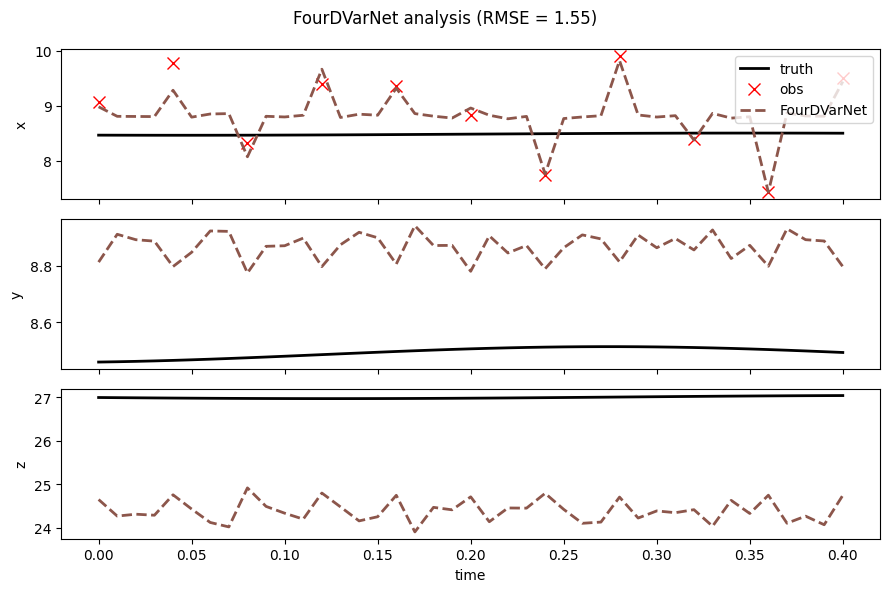

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
t = jnp.arange(prob.T_plus_1) * prob.dt
for i, ax in enumerate(axs):
    ax.plot(t, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_t = t[prob.mask[:, i] > 0.5]
    if len(obs_t) > 0:
        ax.plot(obs_t, prob.obs[prob.mask[:, i] > 0.5, i], "rx", ms=8, label="obs")
    ax.plot(t, result.mean[:, i], "C5--", lw=2, label="FourDVarNet")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right")
axs[-1].set_xlabel("time")
fig.suptitle(f"FourDVarNet analysis (RMSE = {result.rmse_total:.2f})")
fig.tight_layout()
plt.show()

## 6. Discussion

A few seconds of training, 5 unrolled solver steps, and FourDVarNet
beats strong-4DVar on RMSE. The reason: the learned modulator
adapts the step size and direction to the local geometry of the
cost surface, while BFGS treats every problem instance as if it
were the first one it ever saw.

Important caveat: this only generalises **within the training
distribution**. Test on a problem drawn from the same
`generate_problem` distribution and FourDVarNet wins; test on a
different observation density or noise level and it can fail
gracefully or catastrophically depending on training-set coverage.
The next notebook ([Amortized](07_amortized_posterior.ipynb))
pushes this to its extreme: no inner solve at all, just a forward
pass through a learned head. Even more accurate, even more
distribution-sensitive.